In [18]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


determine keypoint visibility by rendering

In [19]:
import os 
import cv2 
import numpy as np

from pytorch3d.renderer import PerspectiveCameras, TexturesVertex
from pytorch3d.structures import Meshes


if "PYOPENGL_PLATFORM" not in os.environ:
    os.environ["PYOPENGL_PLATFORM"] = "egl"
import pyrender
from sam_3d_body.visualization.renderer import Renderer

In [20]:
import torch
import numpy as np
import torch.nn as nn
import smplx 
import pytorch_lightning as pl
from einops import rearrange

from pytorch3d.structures import Meshes
from pytorch3d.renderer import (
    FoVPerspectiveCameras,
    PerspectiveCameras,
    RasterizationSettings,
    MeshRenderer,
    MeshRasterizer,
    TexturesVertex
)
from pytorch3d.renderer.blending import hard_rgb_blend, BlendParams



class SimpleShader(nn.Module):
    def __init__(self, device="cpu", blend_params=None):
        super().__init__()
        self.blend_params = blend_params if blend_params is not None else BlendParams()

    def forward(self, fragments, meshes, **kwargs) -> torch.Tensor:
        blend_params = kwargs.get("blend_params", self.blend_params)
        texels = meshes.sample_textures(fragments)
        
        # If we have more than 3 channels, return all channels
        if texels.shape[-1] > 3:
            # Use the alpha channel from fragments for masking
            alpha = fragments.zbuf[..., 0] > -1

            # Expand alpha to match number of channels
            alpha = alpha.unsqueeze(-1).unsqueeze(-1) # no need to expand as texels as same alpha for all channels

            # Return all channels with alpha mask
            return torch.cat([texels, alpha], dim=-1).squeeze() # (N, H, W, C+1)
        
        # For RGB textures, use standard blending
        images = hard_rgb_blend(texels, fragments, blend_params)
        return images  # (N, H, W, 3) RGBA image for RGB, or (N, H, W, C+1) for multi-channel
    

class FeatureRenderer(pl.LightningModule):
    def __init__(self, image_size=(256, 192)):
        super().__init__()
        self.image_size = image_size

        raster_settings = RasterizationSettings(
            image_size=self.image_size,
            blur_radius=0.0,
            faces_per_pixel=4,
            bin_size=None,
            max_faces_per_bin=160000 # Otherwise overflows 
        )
        
        self.renderer = MeshRenderer(
            rasterizer=MeshRasterizer(
                raster_settings=raster_settings
            ),
            shader=SimpleShader()
        )
        # self.register_buffer('faces', smpl_faces)

        self._set_cameras(PerspectiveCameras().to(self.device))
    

    def forward(self, mesh, **kwargs):

        images = self.renderer(mesh)

        # Get fragments to determine visible parts of the mesh
        fragments = self.renderer.rasterizer(mesh)
        
        # Extract visible mesh parts
        # visible_faces = self._extract_visible_faces(mesh, fragments)

        ret = {
            'maps': images[..., :-1],  # All channels except the last (alpha)
            'mask': images[..., -1],   # Last channel is the alpha/mask
            'fragments': fragments,
            # 'visible_faces': visible_faces  # Indices of visible faces in original mesh
        }

        return ret
    

    def _set_cameras(self, cameras):
        self.renderer.rasterizer.cameras = cameras
        self.renderer.shader.cameras = cameras

    def _extract_visible_faces(self, mesh, fragments):

        # Get the face indices that are visible (have valid depth values)
        visible_faces = fragments.pix_to_face[..., 0]  # (N, H, W)
        valid_mask = visible_faces >= 0  # Faces with valid depth
        
        # Get unique face indices that are visible
        unique_visible_faces = torch.unique(visible_faces[valid_mask])
        
        # Remove the -1 (invalid face) index if present
        unique_visible_faces = unique_visible_faces[unique_visible_faces >= 0]
        
        return unique_visible_faces
    


def project(points, cam_trans, cam_int, return_depth=True):
    points = points + cam_trans
    depth = points[..., -1]
    projected_points = points / points[..., -1].unsqueeze(-1)
    projected_points = torch.einsum("bij, bkj->bki", cam_int, projected_points)
    if return_depth:
        return projected_points, depth
    else:
        return projected_points


In [21]:
DATA_BASE_PATH = "/scratch/cq244/BEDLAM/data/"
NPZ_PATH = os.path.join(DATA_BASE_PATH, "training_labels/all_npz_12_training_extra_mhr/20221010_3_1000_batch01hand_6fps.npz")
IMAGE_DIR = os.path.join(DATA_BASE_PATH, "training_images/20221010_3_1000_batch01hand_6fps")
MHR_MODEL_PATH = "/scratch/cq244/sam-3d-body/checkpoints/sam-3d-body-dinov3/assets/mhr_model.pt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data = np.load(NPZ_PATH)
print(list(data.keys()))
print(data['imgname'][:2])

print(f"identity_coeffs: {data['identity_coeffs'].shape}")
print(f"lbs_model_params: {data['lbs_model_params'].shape}")
print(f"face_expr_coeffs: {data['face_expr_coeffs'].shape}")


mhr_model = torch.jit.load(
    MHR_MODEL_PATH,
    map_location=("cuda" if torch.cuda.is_available() else "cpu"),
)


ckpt = torch.load("/scratch/cq244/sam-3d-body/checkpoints/sam-3d-body-dinov3/model.ckpt", weights_only=False)
print(type(ckpt))
for key in ckpt.keys():
    if 'faces' in key:
        print(key)

faces = ckpt['head_pose.faces'].cpu().detach().numpy()
print(faces.shape)
# del ckpt
# import gc
# gc.collect()
# torch.cuda.empty_cache()

chunk_size = 1024
vertices, joints3d = [], []
with torch.no_grad():
    num_samples = data['identity_coeffs'].shape[0]
    for i in range(0, num_samples, chunk_size):
        end_idx = min(i + chunk_size, num_samples)
        mhr_input = {
            'identity_coeffs': torch.tensor(data['identity_coeffs'][i:end_idx], dtype=torch.float32, device=device),
            'model_parameters': torch.tensor(data['lbs_model_params'][i:end_idx], dtype=torch.float32, device=device),
            'face_expr_coeffs': torch.tensor(data['face_expr_coeffs'][i:end_idx], dtype=torch.float32, device=device),
        }
        verts, skeleton = mhr_model(**mhr_input)
        j3d = skeleton[:, :, :3]
        vertices.append(verts.cpu().detach().numpy())
        joints3d.append(j3d.cpu().detach().numpy())
        
        if i > 5000:
            break 

vertices = np.concatenate(vertices, axis=0)
joints3d = np.concatenate(joints3d, axis=0)

print(vertices.shape, joints3d.shape)



['imgname', 'center', 'scale', 'pose_cam', 'pose_world', 'shape', 'trans_cam', 'trans_world', 'gtkps', 'cam_int', 'cam_ext', 'gender', 'proj_verts', 'serno', 'lbs_model_params', 'identity_coeffs', 'face_expr_coeffs', 'mhr_keypoints_2d']
['seq_000000/seq_000000_0000.png' 'seq_000000/seq_000000_0005.png']
identity_coeffs: (89728, 45)
lbs_model_params: (89728, 204)
face_expr_coeffs: (89728, 72)
<class 'dict'>
head_pose.faces
head_pose_hand.faces
(36874, 3)


KeyboardInterrupt: 

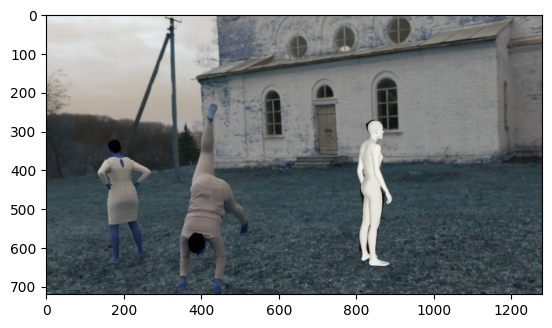

In [ ]:

focal_length = data["cam_int"][0, 0, 0]
renderer = Renderer(focal_length=focal_length, faces=faces)


for i in range(1, num_samples):
    image_for_render = cv2.imread(os.path.join(IMAGE_DIR, 'png', data['imgname'][i]))
    trans_cam = data['trans_cam'][i]
    cam_t = data['cam_ext'][i, :3, -1]
    cam_t += trans_cam
    cam_center = (
        data['cam_int'][i, 0, 2],
        data['cam_int'][i, 1, 2]
    )
    verts = vertices[i]

    renderer_output = renderer(
        verts / 100., 
        cam_t,
        image_for_render,
        scene_bg_color = (1, 1, 1),
        camera_center = cam_center
    )

    break

img = renderer_output 
import matplotlib.pyplot as plt

plt.imshow(img)
plt.show()




In [ ]:
def check_joint_visibility(
    j2d,
    j2d_depth,
    fragments,     
    depth_tolerance=0.01,
):
    zbuf = fragments.zbuf  # (N, H, W, K)
    zbuf = torch.flip(zbuf, dims=[1, 2]) # NOTE: Flip here similar to the image 
    N, H, W, K = zbuf.shape

    x_pixel, y_pixel = j2d[:, 0], j2d[:, 1]

    # Round to integer pixel coordinates for indexing
    x_idx = torch.clamp(torch.round(x_pixel).long(), 0, W - 1)
    y_idx = torch.clamp(torch.round(y_pixel).long(), 0, H - 1)

    # Check if joints are within image bounds
    in_bounds = (x_pixel >= 0) & (x_pixel < W) & (y_pixel >= 0) & (y_pixel < H)

    # Get all depths from z-buffer at joint pixel locations: (N_joints, K)
    depths_at_pixels = zbuf[0, y_idx, x_idx, :]  # (N_joints, K)

    # Valid depths: > -1
    valid_mask = depths_at_pixels > -1

    # Count how many faces are strictly in front of the joint along the ray
    # A face is "in front" if its depth is smaller than the joint depth minus a tolerance.
    # This allows the joint to lie slightly behind the first surface (inside the mesh),
    # but we treat it as occluded if there is more than one distinct surface in front.
    front_faces = depths_at_pixels < (j2d_depth.unsqueeze(1) - depth_tolerance)  # (N_joints, K)
    front_faces = front_faces & valid_mask
    num_front_faces = front_faces.sum(dim=1)  # (N_joints,)

    # Require at least one valid depth sample at the pixel
    any_valid = valid_mask.any(dim=1)

    # Visibility rule for joints inside the mesh:
    # - in image bounds
    # - at least one valid depth at that pixel
    # - at most one face in front of the joint
    visibility = in_bounds & any_valid & (num_front_faces <= 1)

    return visibility.cpu().numpy()


/tmp/ipykernel_3245671/2450558979.py:61: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(j2d_depth, device=device, dtype=torch.float32)[0],
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.5999999..1.0000001].


PyTorch3D renderer output shape: (360, 640, 3)
Output range: [0.600, 1.000]


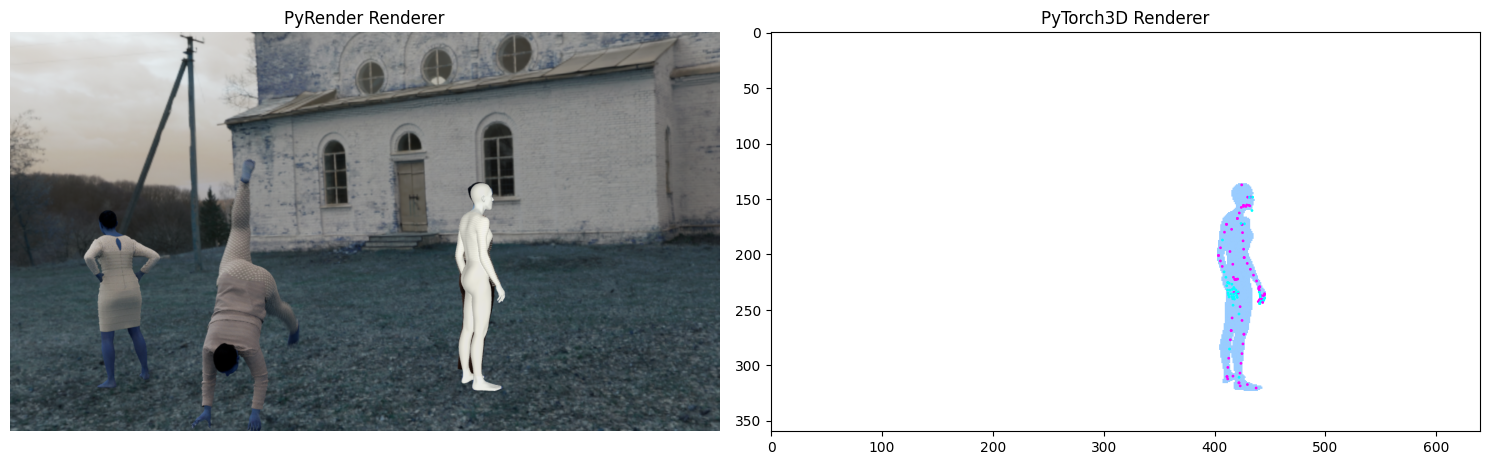

In [ ]:
# Use the same data as before
i = 1
image_for_render = cv2.imread(os.path.join(IMAGE_DIR, 'png', data['imgname'][i]))

downscale_by = 2
H, W = image_for_render.shape[:2]
H, W = int(H / downscale_by), int(W / downscale_by)

trans_cam = data['trans_cam'][i]
cam_t = data['cam_ext'][i, :3, -1]
cam_t += trans_cam
cam_int = data['cam_int'][i]
focal_length = cam_int[0, 0] / downscale_by
cam_int[0, 0] /= downscale_by
cam_int[1, 1] /= downscale_by
cam_int[0, 2] /= downscale_by
cam_int[1, 2] /= downscale_by

cam_center = (
    cam_int[0, 2].astype(float),
    cam_int[1, 2].astype(float)
)
verts = vertices[i].astype(float) / 100.
j3d = joints3d[i].astype(float) / 100. 


j2d, j2d_depth = project(
    torch.tensor(j3d, device=device, dtype=torch.float32)[None], 
    torch.tensor(cam_t, device=device, dtype=torch.float32)[None], 
    torch.tensor(cam_int, device=device, dtype=torch.float32)[None],
    return_depth=True
)
j2d = j2d.cpu().numpy()

renderer = FeatureRenderer(image_size=(H, W))

cameras = PerspectiveCameras(
    focal_length=torch.tensor(focal_length, device=device, dtype=torch.float32)[None],
    principal_point=torch.tensor(cam_center, device=device, dtype=torch.float32)[None, :],
    T=torch.tensor(cam_t, device=device, dtype=torch.float32)[None, :],
    image_size=torch.tensor([H, W], device=device, dtype=torch.float32)[None, :],
    in_ndc=False,
    device=device
)
renderer._set_cameras(cameras)

textures = torch.ones_like(torch.tensor(verts, dtype=torch.float32, device=device)) * torch.tensor([0.6, 0.8, 1.0], dtype=torch.float32, device=device)
mesh = Meshes(
    verts=[torch.tensor(verts, dtype=torch.float32, device=device)], 
    faces=[torch.tensor(faces, dtype=torch.long, device=device)],
    textures=TexturesVertex(verts_features=[textures])
)

pytorch3d_output = renderer(mesh)
fragments = pytorch3d_output['fragments']
pytorch3d_output = pytorch3d_output['maps'][0].cpu().numpy()
pytorch3d_output = pytorch3d_output[::-1, ::-1, :]

visibility = check_joint_visibility(
    torch.tensor(j2d, device=device, dtype=torch.float32)[0],
    torch.tensor(j2d_depth, device=device, dtype=torch.float32)[0],
    fragments=fragments,
    depth_tolerance=0.01,  # Adjust based on your scale
)


print(f"PyTorch3D renderer output shape: {pytorch3d_output.shape}")
print(f"Output range: [{pytorch3d_output.min():.3f}, {pytorch3d_output.max():.3f}]")

# Compare with pyrender output
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
axes[0].imshow(img)
axes[0].set_title('PyRender Renderer')
axes[0].axis('off')
axes[1].imshow(pytorch3d_output)
axes[1].set_title('PyTorch3D Renderer')
scatter = axes[1].scatter(
    j2d[0, :, 0], 
    j2d[0, :, 1], 
    c=visibility, 
    cmap='cool', 
    s=1, 
    vmin=0, 
    vmax=1
)
# plt.colorbar(scatter, ax=axes[1], label='Visibility')
# axes[1].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
print(fragments.zbuf.shape)
print(fragments.zbuf.min(), fragments.zbuf.max())



torch.Size([1, 720, 1280, 4])
tensor(-1., device='cuda:0') tensor(6.4843, device='cuda:0')


In [ ]:
print(j2d[0, :10])
print(j2d_depth[0, :10])
print(fragments.zbuf.shape)


print(f"Visible joints: {visibility.sum()} / {len(visibility)}")
print(f"Visibility mask: {visibility}")


[[844.1601  507.40283   1.     ]
 [841.67944 444.33862   1.     ]
 [836.8046  444.95306   1.     ]
 [830.1078  537.2743    1.     ]
 [822.55414 620.3207    1.     ]
 [822.52185 620.5108    1.     ]
 [823.7279  624.48236   1.     ]
 [833.29083 619.49207   1.     ]
 [844.2632  621.66425   1.     ]
 [828.5908  553.9518    1.     ]]
tensor([6.1856, 6.1756, 6.2120, 6.3207, 6.3531, 6.3531, 6.3658, 6.3945, 6.4382,
        6.3272], device='cuda:0')
torch.Size([1, 720, 1280, 4])
Visible joints: 87 / 127
Visibility mask: [False  True  True  True  True  True  True  True False  True  True  True
  True  True  True False  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True False  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True False  True  True  True False
  True  True False False False  True  True  True  True  True  True  True
  True  True False  True  True False False Fa